# Metric sensitivity tests

This notebook checks two path-distribution metrics implemented in `src.metrics`:

- $\mathbb{E}\,\sup_t \|S_t^{real} - S_t^{generated}\|^2$ for paired paths.
- Marginal Wasserstein-1 distance at each time point, aggregated as average W1 and maximum W1.

Two controlled experiments are included:

1. One-dimensional Gaussian noise with fixed baseline parameters and generated parameters moving away over the time grid.
2. One-dimensional GBM with fixed baseline parameters and generated drift/volatility moving away over the time grid.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.metrics import compute_path_metrics

In [2]:
def set_scientific_style():
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "axes.linewidth": 0.8,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "lines.linewidth": 1.2,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def format_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, color="0.88", linewidth=0.6)
    ax.set_axisbelow(True)


set_scientific_style()

In [9]:
torch.manual_seed(123)

dtype = torch.float64
device = torch.device("cpu")

n_paths = 10000
n_steps = 64
num_quantiles = 512

ts = torch.linspace(0.0, 1.0, n_steps, dtype=dtype, device=device)
tau = ts.view(1, n_steps, 1)

## Helper functions

In [10]:
def metric_values(real_paths, generated_paths):
    metrics = compute_path_metrics(
        real_paths,
        generated_paths,
        num_quantiles=num_quantiles,
    )
    return {
        "e_sup": float(metrics["expected_supremum_squared_error"].detach().cpu()),
        "w1_average": float(metrics["marginal_w1_average"].detach().cpu()),
        "w1_max": float(metrics["marginal_w1_max"].detach().cpu()),
    }


def collect_metric_curve(real_paths, generated_paths_by_level, levels):
    rows = []
    for level, generated_paths in zip(levels, generated_paths_by_level):
        row = {"level": float(level)}
        row.update(metric_values(real_paths, generated_paths))
        rows.append(row)
    return rows


def values(rows, key):
    return np.asarray([row[key] for row in rows], dtype=float)


def plot_metric_sensitivity(mean_rows, variance_rows, *, title, mean_xlabel, variance_xlabel):
    fig, axes = plt.subplots(2, 3, figsize=(12.0, 6.4), sharex="row")
    metric_specs = [
        ("e_sup", r"$\mathbb{E}\,\sup_t \|S_t^{real} - S_t^{generated}\|^2$"),
        ("w1_average", "Average marginal W1"),
        ("w1_max", "Maximum marginal W1"),
    ]

    x_mean = values(mean_rows, "level")
    x_var = values(variance_rows, "level")

    for col, (key, ylabel) in enumerate(metric_specs):
        axes[0, col].plot(x_mean, values(mean_rows, key), color="#1f77b4", marker="o", markersize=3.5)
        axes[0, col].set_ylabel(ylabel)
        axes[0, col].set_title("Mean perturbation")
        format_axis(axes[0, col])

        axes[1, col].plot(x_var, values(variance_rows, key), color="#d62728", marker="o", markersize=3.5)
        axes[1, col].set_ylabel(ylabel)
        axes[1, col].set_title("Variance perturbation")
        format_axis(axes[1, col])

    for ax in axes[0, :]:
        ax.set_xlabel(mean_xlabel)
    for ax in axes[1, :]:
        ax.set_xlabel(variance_xlabel)

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig

## 1. Gaussian noise

Baseline paths are independent one-dimensional Gaussian samples with fixed $\mu_0$ and $\sigma_0$ at every time point. Generated paths use parameters that move linearly away from baseline over the time grid:

- Mean experiment: $\mu_t = \mu_0 + \Delta_\mu t$, $\sigma_t = \sigma_0$.
- Variance experiment: $\mu_t = \mu_0$, $\sigma_t = \sigma_0(1 + a t)$.

In [11]:
mu0 = 0.0
sigma0 = 1.0

eps_gaussian = torch.randn(n_paths, n_steps, 1, dtype=dtype, device=device)
gaussian_real = mu0 + sigma0 * eps_gaussian

mean_shifts = torch.linspace(0.0, 1.0, 50, dtype=dtype, device=device)
std_slope_levels = torch.linspace(0.0, 1.0, 50, dtype=dtype, device=device)

gaussian_mean_generated = [
    (mu0 + shift * tau) + sigma0 * eps_gaussian
    for shift in mean_shifts
]

gaussian_variance_generated = [
    mu0 + sigma0 * (1.0 + level * tau) * eps_gaussian
    for level in std_slope_levels
]

gaussian_mean_rows = collect_metric_curve(gaussian_real, gaussian_mean_generated, mean_shifts)
gaussian_variance_rows = collect_metric_curve(
    gaussian_real,
    gaussian_variance_generated,
    (1.0 + std_slope_levels).pow(2),
)

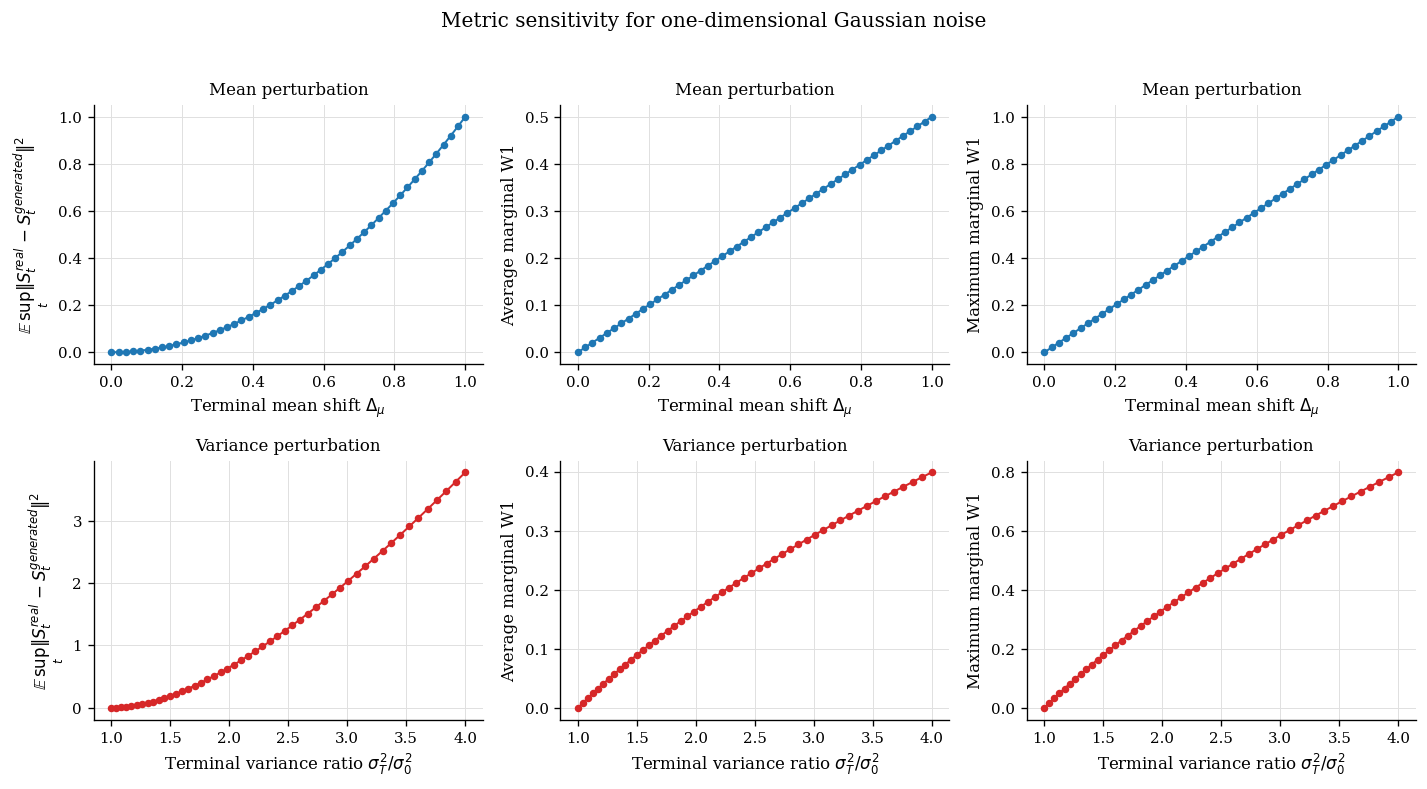

In [12]:
fig = plot_metric_sensitivity(
    gaussian_mean_rows,
    gaussian_variance_rows,
    title="Metric sensitivity for one-dimensional Gaussian noise",
    mean_xlabel=r"Terminal mean shift $\Delta_\mu$",
    variance_xlabel=r"Terminal variance ratio $\sigma_T^2 / \sigma_0^2$",
)
plt.show()

## 2. Geometric Brownian motion

Baseline paths follow

$$dS_t = \mu_0 S_t dt + \sigma_0 S_t dW_t.$$

Generated paths move away from the baseline through time-varying drift or volatility:

- Drift experiment: $\mu_t = \mu_0 + \Delta_\mu t$, $\sigma_t = \sigma_0$.
- Variance experiment: $\mu_t = \mu_0$, $\sigma_t = \sigma_0(1 + a t)$.

All paths are paired by using the same Brownian increments for baseline and generated samples.

In [13]:
def simulate_gbm_from_parameters(mu_t, sigma_t, eps, *, s0=1.0, dt=1.0 / (n_steps - 1)):
    # mu_t and sigma_t have shape (1, T - 1, 1); eps has shape (N, T - 1, 1).
    log_increments = (mu_t - 0.5 * sigma_t.pow(2)) * dt + sigma_t * (dt ** 0.5) * eps
    log_paths = torch.cat(
        [
            torch.zeros(eps.size(0), 1, 1, dtype=eps.dtype, device=eps.device),
            torch.cumsum(log_increments, dim=1),
        ],
        dim=1,
    )
    return s0 * torch.exp(log_paths)


s0 = 1.0
gbm_mu0 = 0.05
gbm_sigma0 = 0.20
dt = 1.0 / (n_steps - 1)
tau_inc = ts[:-1].view(1, n_steps - 1, 1)

eps_gbm = torch.randn(n_paths, n_steps - 1, 1, dtype=dtype, device=device)

mu_base_t = torch.full_like(tau_inc, gbm_mu0)
sigma_base_t = torch.full_like(tau_inc, gbm_sigma0)
gbm_real = simulate_gbm_from_parameters(mu_base_t, sigma_base_t, eps_gbm, s0=s0, dt=dt)

gbm_drift_shifts = torch.linspace(0.0, 0.50, 13, dtype=dtype, device=device)
gbm_vol_slope_levels = torch.linspace(0.0, 1.50, 13, dtype=dtype, device=device)

gbm_mean_generated = [
    simulate_gbm_from_parameters(
        gbm_mu0 + shift * tau_inc,
        sigma_base_t,
        eps_gbm,
        s0=s0,
        dt=dt,
    )
    for shift in gbm_drift_shifts
]

gbm_variance_generated = [
    simulate_gbm_from_parameters(
        mu_base_t,
        gbm_sigma0 * (1.0 + level * tau_inc),
        eps_gbm,
        s0=s0,
        dt=dt,
    )
    for level in gbm_vol_slope_levels
]

gbm_mean_rows = collect_metric_curve(gbm_real, gbm_mean_generated, gbm_drift_shifts)
gbm_variance_rows = collect_metric_curve(
    gbm_real,
    gbm_variance_generated,
    (1.0 + gbm_vol_slope_levels).pow(2),
)

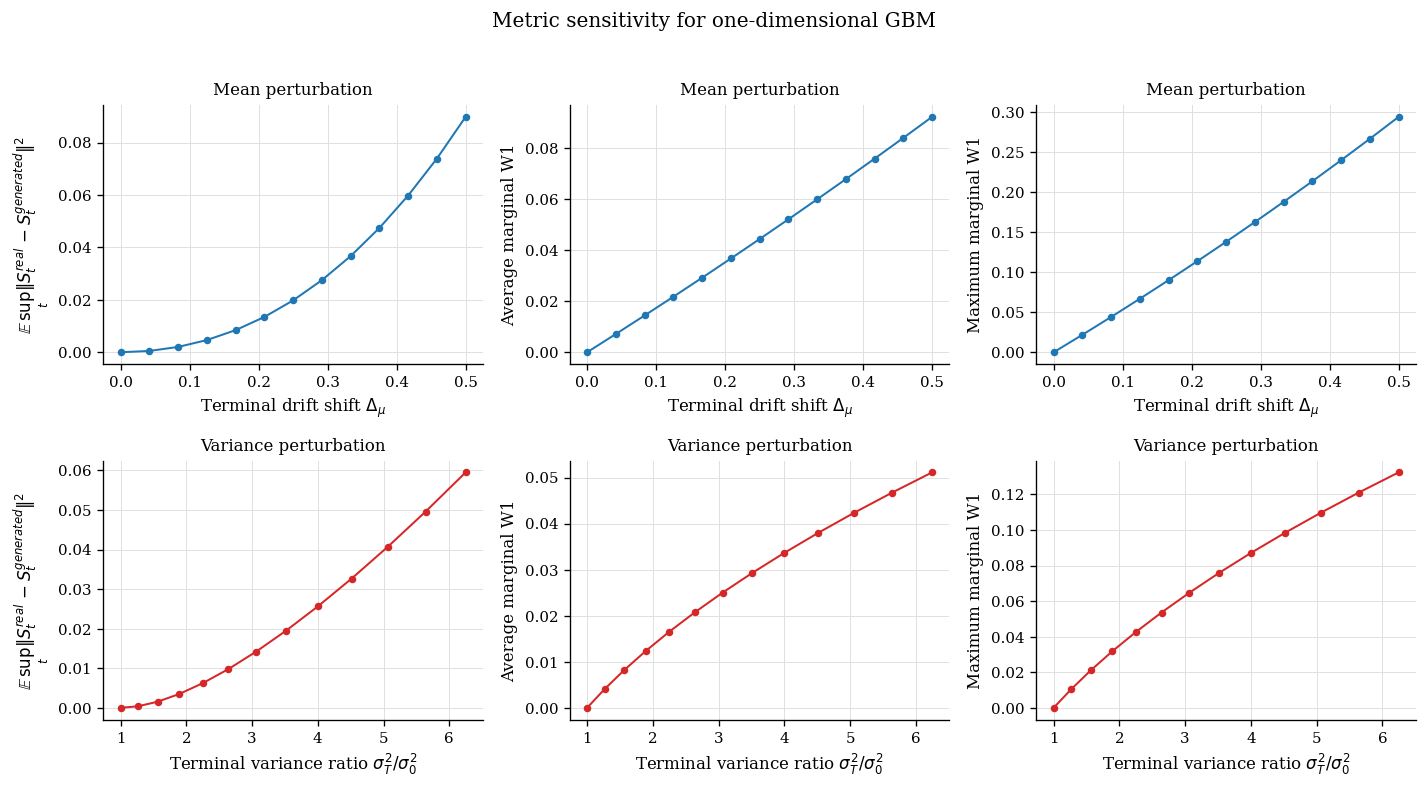

: 

In [ ]:
fig = plot_metric_sensitivity(
    gbm_mean_rows,
    gbm_variance_rows,
    title="Metric sensitivity for one-dimensional GBM",
    mean_xlabel=r"Terminal drift shift $\Delta_\mu$",
    variance_xlabel=r"Terminal variance ratio $\sigma_T^2 / \sigma_0^2$",
)
plt.show()